# Binary recovery with grid search and HMC

The first and simplest thing you will want to do in a lot of interferometric datasets is to look for faint companions at high resolution: this is often why we're in the game in the first place!

This tutorial walks through end-to-end binary recovery on synthetic interferometric observables, starting from a coarse likelihood grid and continuing through vanilla HMC and Fisher-reparameterized HMC. 

First, let's import everything we will need.

In [1]:
import warnings
import jax
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
from jax.flatten_util import ravel_pytree

warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

from drpangloss.models import BinaryModelCartesian, loglike
from drpangloss.oidata import OIData
from drpangloss.grid_fit import likelihood_grid
from drpangloss.inference import fisher_matrix, fisher_projection
from drpangloss.plotting import (
    posterior_predictive_summary,
    plot_data_model_correlation,
    plot_likelihood_grid,
    plot_chainconsumer_diagnostics,
    diagnostics_table_from_samples,
    truth_cartesian_and_polar,
)

## Simulate Data

We're going simulate $V^2$ and phase observables from a known binary model, add realistic noise, and wrap this into the `OIData` object that `drpangloss` uses to handle data.

In [2]:
rng = onp.random.default_rng(42)
n_bl = 24
u = jnp.array(rng.uniform(-28.0, 28.0, size=n_bl))
v = jnp.array(rng.uniform(-28.0, 28.0, size=n_bl))
wavel = jnp.array([4.8e-6])

truth = {"dra": 120.0, "ddec": -80.0, "flux": 4e-3}
model_true = BinaryModelCartesian(**truth)
cvis_true = model_true.model(u, v, wavel)

vis_true = jnp.abs(cvis_true) ** 2
phi_true = jnp.rad2deg(jnp.angle(cvis_true))

# Synthetic noise as percentage of data scale (phase in degrees), boosted SNR by 5x.
vis_scale = jnp.maximum(jnp.median(vis_true), 1e-6)
phi_scale = jnp.maximum(jnp.median(jnp.abs(phi_true)), 5.0)
d_vis = 0.001 * vis_scale * jnp.ones_like(vis_true)
d_phi = 0.004 * phi_scale * jnp.ones_like(phi_true)

vis_obs = vis_true + d_vis * jnp.array(rng.normal(size=vis_true.shape))
phi_obs = phi_true + d_phi * jnp.array(rng.normal(size=phi_true.shape))

data = OIData(
    {
        "u": u,
        "v": v,
        "wavel": wavel,
        "vis": vis_obs,
        "d_vis": d_vis,
        "phi": phi_obs,
        "d_phi": d_phi,
        "phi_unit": "deg",
        "i_cps1": None,
        "i_cps2": None,
        "i_cps3": None,
        "v2_flag": True,
        "cp_flag": False,
    }
)

## Grid Search for Companions

Because Jax is so fast and parallelizes so well, we can run very efficient grid searches compared to previous implementations. This is often the first place you will want to start in searching for a companion.

First we have to define our grid dictionary `samples` in our chosen coordinates - we will use Cartesian $(\Delta\mathrm{RA}, \Delta\mathrm{Dec}, \mathrm{flux})$ but you can just as well use polar coordinates in separation, position angle, and contrast if you use `BinaryModelAngular` instead.

In [3]:
samples = {
    "dra": jnp.linspace(-250.0, 250.0, 81),
    "ddec": jnp.linspace(-250.0, 250.0, 81),
    "flux": 10 ** jnp.linspace(-4.5, -1.5, 60),
}

ll_cube = likelihood_grid(data, BinaryModelCartesian, samples)
max_idx = jnp.unravel_index(jnp.argmax(ll_cube), ll_cube.shape)
grid_est = {
    "dra": float(samples["dra"][max_idx[0]]),
    "ddec": float(samples["ddec"][max_idx[1]]),
    "flux": float(samples["flux"][max_idx[2]]),
}

print(
    "Grid estimate: dra={:.3g} mas, ddec={:.3g} mas, flux={:.2g}".format(
        grid_est["dra"], grid_est["ddec"], grid_est["flux"]
    )
)

Grid estimate: dra=119 mas, ddec=-81.2 mas, flux=0.0038


## Visualize the Grid
We have plotting helpers to achieve a consistent style and handle metadata: we'll see that the binary is very accurately recovered just from this grid search!

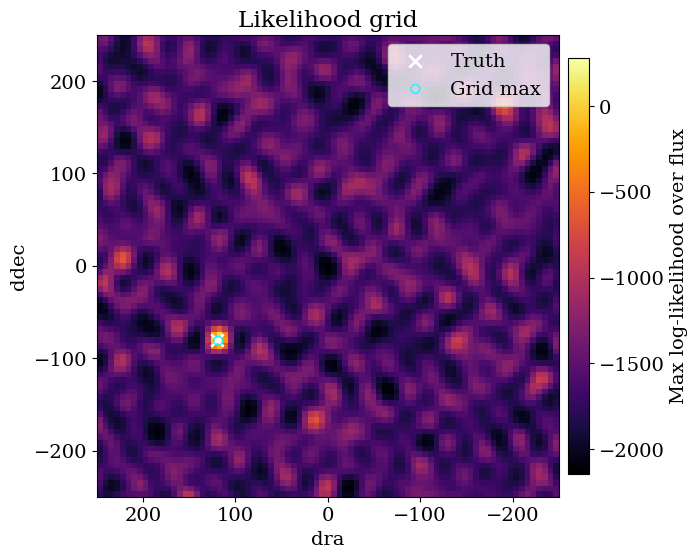

In [4]:
ll_2d = ll_cube.max(
    axis=2
)  # find max log-likelihood over flux for each (dra, ddec) pair
plot_likelihood_grid(
    ll_2d,
    samples,
    truths=truth,
    best_point=grid_est,
    colorbar_label="Max log-likelihood over flux",
);

## Uncertainty quantification with Hamiltonian Monte Carlo

You may have used MCMC before, for example with [Metropolis-Hastings](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) or [`emcee`](http://emcee.readthedocs.io/), but these will often perform poorly in high dimensions. Because we're using Jax and have gradients, we can use [Hamiltonian Monte Carlo](https://arxiv.org/abs/1701.02434), which can work in arbitrarily high dimensions. We will use [`numpyro`](https://num.pyro.ai/en/stable/) to handle this:

In [5]:
params = ["dra", "ddec", "flux"]


# Define a simple physical-parameter HMC model with bounded priors.
def model_hmc(oidata):
    dra = numpyro.sample("dra", dist.Uniform(-300.0, 300.0))
    ddec = numpyro.sample("ddec", dist.Uniform(-300.0, 300.0))
    log10_flux = numpyro.sample("log10_flux", dist.Uniform(-6.0, -1.0))
    flux = 10.0**log10_flux
    ll = loglike([dra, ddec, flux], params, oidata, BinaryModelCartesian)
    numpyro.factor("loglike", ll)


# Initialize near the grid maximum for robust convergence in this toy setup.
init_values = {
    "dra": float(grid_est["dra"]),
    "ddec": float(grid_est["ddec"]),
    "log10_flux": float(jnp.log10(max(grid_est["flux"], 1e-12))),
}
kernel = NUTS(model_hmc, init_strategy=init_to_value(values=init_values))
mcmc = MCMC(
    kernel, num_warmup=800, num_samples=2000, num_chains=1, progress_bar=False
)
mcmc.run(jax.random.PRNGKey(2026), oidata=data)
posterior = mcmc.get_samples()

summary = {
    "dra_median": float(jnp.median(posterior["dra"])),
    "ddec_median": float(jnp.median(posterior["ddec"])),
    "flux_median": float(jnp.median(10.0 ** posterior["log10_flux"])),
}
print(
    "HMC estimate: dra={:.3g} mas, ddec={:.3g} mas, flux={:.2g}".format(
        summary["dra_median"], summary["ddec_median"], summary["flux_median"]
    )
)

HMC estimate: dra=120 mas, ddec=-80.1 mas, flux=0.0039


## Diagnostic Tables
We have helper functions to reformat the posterior draws into a dataframe.

In [6]:
# Convert vanilla posterior samples into diagnostics table for later comparison plots.
hmc_results = diagnostics_table_from_samples(
    posterior,
    flux_key="log10_flux",
    log10_flux=True,
)

print(
    "HMC estimate from diagnostics table: dra={:.3g} mas, ddec={:.3g} mas, flux={:.2g}".format(
        float(hmc_results["dra"].median()),
        float(hmc_results["ddec"].median()),
        float(hmc_results["flux"].median()),
    )
)

HMC estimate from diagnostics table: dra=120 mas, ddec=-80.1 mas, flux=0.0039


## Fisher Reparametrization
If you are finding that HMC is failing to converge quickly on high-SNR data, it can be because the posteriors are often highly correlated between parameters. The good thing is that [`zodiax`](https://github.com/LouisDesdoigts/zodiax), the backend of `drpangloss`, has helper functions to reparametrize problems into their natural scales, parametrized by a fiducial value for all parameters `x0` and the [Fisher Information Matrix](https://en.wikipedia.org/wiki/Fisher_information).

See [this `zodiax` tutorial](https://github.com/LouisDesdoigts/zodiax_tutorials/blob/main/optimisation_tools.ipynb) for more information!

In [7]:
x0_dict = {
    "dra": grid_est["dra"],
    "ddec": grid_est["ddec"],
    "log10_flux": float(jnp.log10(max(grid_est["flux"], 1e-12))),
}
x0, unravel = ravel_pytree(x0_dict)


# Build local Fisher geometry around x0 for whitening transform.
def objective(x):
    xdict = unravel(x)
    flux = 10.0 ** xdict["log10_flux"]
    values = jnp.array([xdict["dra"], xdict["ddec"], flux])
    return -loglike(values, params, data, BinaryModelCartesian)


F = fisher_matrix(objective, x0, ridge=1e-8)
P = fisher_projection(F)


# Sample in latent coordinates and apply explicit prior correction back to physical priors.
def model_hmc_fisher(oidata):
    u_latent = numpyro.sample(
        "u", dist.Normal(0.0, 1.0).expand([x0.shape[0]]).to_event(1)
    )
    log_q_u = dist.Normal(0.0, 1.0).log_prob(u_latent).sum()
    x = x0 + jnp.dot(
        P, u_latent
    )  # this maps it to the original physical space
    xdict = unravel(x)
    dra = xdict["dra"]
    ddec = xdict["ddec"]
    log10_flux = xdict["log10_flux"]
    flux = 10.0**log10_flux
    numpyro.deterministic("dra", dra)
    numpyro.deterministic("ddec", ddec)
    numpyro.deterministic("flux", flux)
    log_prior_x = (
        dist.Uniform(-300.0, 300.0).log_prob(dra)
        + dist.Uniform(-300.0, 300.0).log_prob(ddec)
        + dist.Uniform(-6.0, -1.0).log_prob(log10_flux)
    )
    numpyro.factor("prior_correction", log_prior_x - log_q_u)
    numpyro.factor(
        "loglike",
        loglike([dra, ddec, flux], params, oidata, BinaryModelCartesian),
    )


kernel_f = NUTS(model_hmc_fisher)
mcmc_f = MCMC(
    kernel_f,
    num_warmup=800,
    num_samples=2000,
    num_chains=1,
    progress_bar=False,
)
mcmc_f.run(jax.random.PRNGKey(2027), oidata=data)
post_f = mcmc_f.get_samples()


print(
    "Fisher HMC estimate: dra={:.3g} mas, ddec={:.3g} mas, flux={:.2g}".format(
        float(jnp.median(post_f["dra"])),
        float(jnp.median(post_f["ddec"])),
        float(jnp.median(post_f["flux"])),
    )
)

Fisher HMC estimate: dra=120 mas, ddec=-80.1 mas, flux=0.0039


## Converting coordinate systems

Our sample reformatter gives you coordinate conversions:

In [8]:
# Convert Fisher-HMC posterior samples and prepare shared diagnostic tables.
fisher_results = diagnostics_table_from_samples(post_f)
truth_cart, truth_polar = truth_cartesian_and_polar(truth)

print(
    "Fisher HMC estimate: sep={:.3g} mas, pa={:.3g} deg".format(
        float(fisher_results["sep"].median()),
        float(fisher_results["pa"].median()),
    )
)

Fisher HMC estimate: sep=144 mas, pa=124 deg


We can visualize the outputs with a corner plot. You can use anything you like, eg [corner.py](https://corner.readthedocs.io/en/latest/) or [pairplots](https://sefffal.github.io/PairPlots.jl/dev/), but we have default helpers for chainconsumer.

We will see that the Fisher and default parametrizations work similarly well, and closely recover the true parameter values to about a 1σ precision. The first plot is a corner plot; the second is a trace, where ideally the chains look like they are stationary. `chainconsumer` and the packages like it contain functions for convergence diagnostics on posterior chains like these.

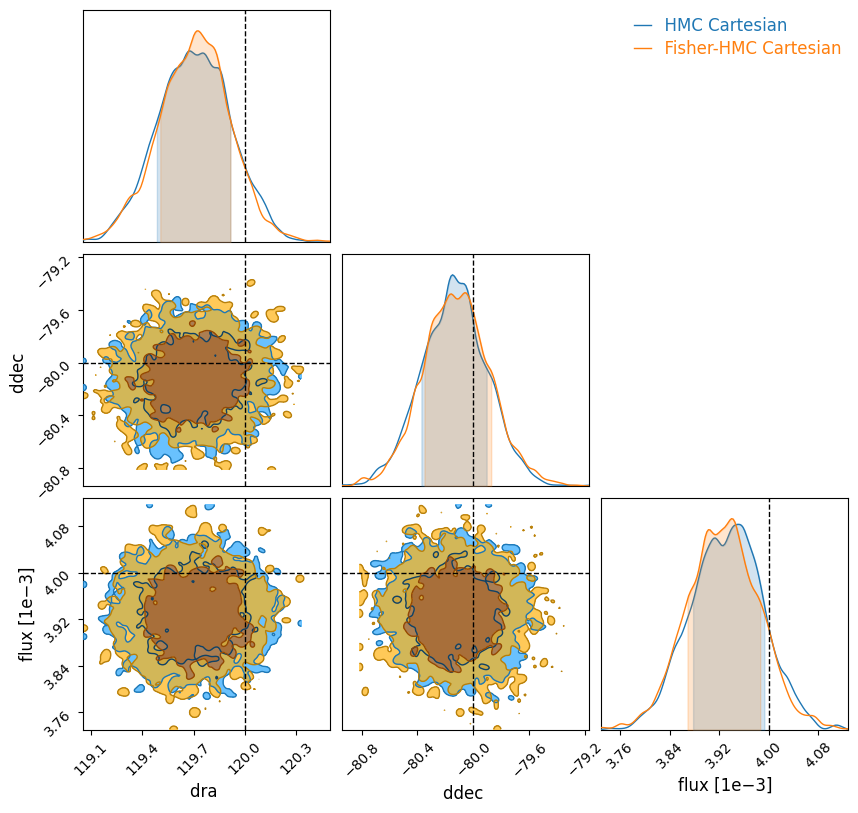

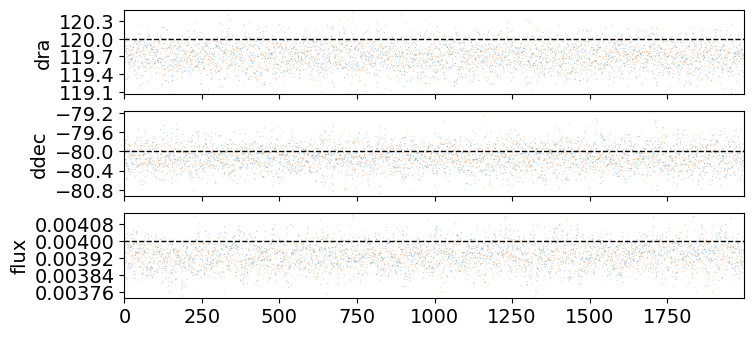

In [9]:
# Cartesian comparison plot
plot_chainconsumer_diagnostics(
    {
        "HMC Cartesian": hmc_results,
        "Fisher-HMC Cartesian": fisher_results,
    },
    columns=["dra", "ddec", "flux"],
    truth=truth_cart,
    colors=["#1f77b4", "#ff7f0e"],
);

And in polar coordinates:

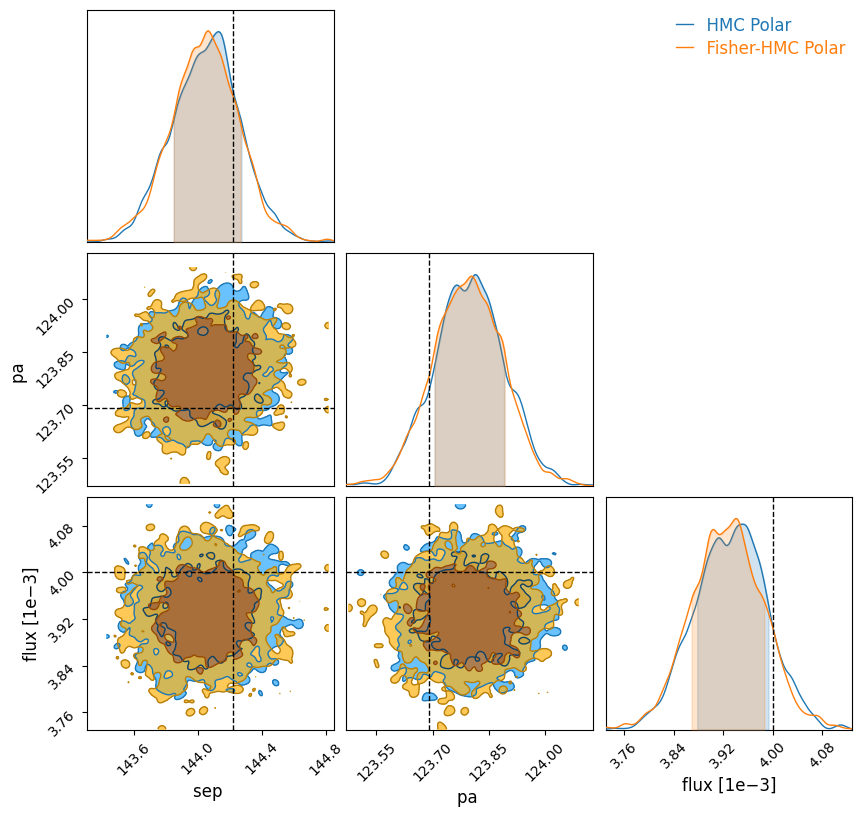

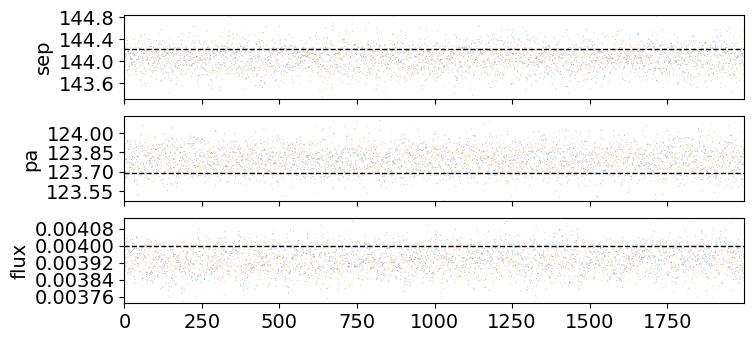

In [10]:
# Polar comparison plot
plot_chainconsumer_diagnostics(
    {
        "HMC Polar": hmc_results,
        "Fisher-HMC Polar": fisher_results,
    },
    columns=["sep", "pa", "flux"],
    truth=truth_polar,
    colors=["#1f77b4", "#ff7f0e"],
);

## Posterior Predictive Checks with Correlation Plots

It is a general rule that you *always* want to check the posterior predictions vs the data when doing Bayesian inference. If the data are time series or curves or images this can be reasonably straightforward; but interferometric data can be hard to visualize. It is common in this field to plot 1:1 correlation plots with data on one axis and the model on the other. 

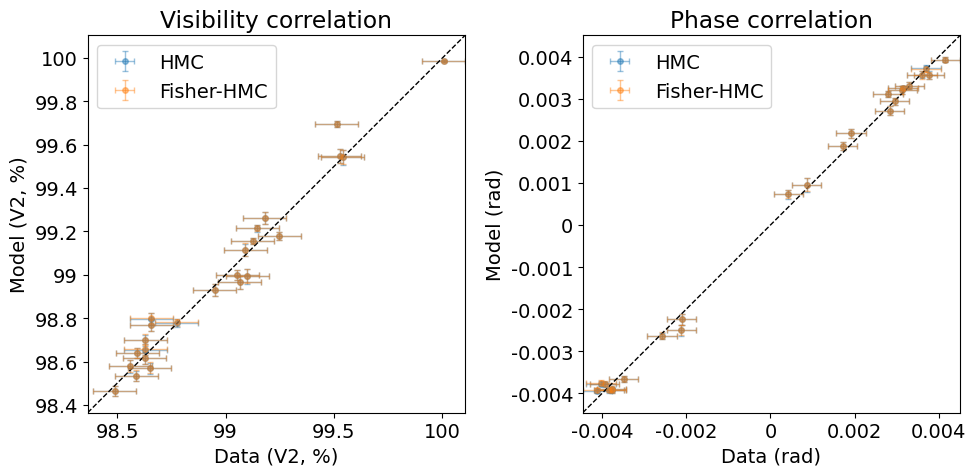

In [11]:
# Posterior predictive correlation: data vs model (HMC and Fisher-HMC)
hmc_pred = posterior_predictive_summary(
    onp.asarray(posterior["dra"]),
    onp.asarray(posterior["ddec"]),
    onp.asarray(10.0 ** posterior["log10_flux"]),
    data,
    BinaryModelCartesian,
)

fisher_pred = posterior_predictive_summary(
    onp.asarray(post_f["dra"]),
    onp.asarray(post_f["ddec"]),
    onp.asarray(post_f["flux"]),
    data,
    BinaryModelCartesian,
)

plot_data_model_correlation(
    data,
    {"HMC": hmc_pred, "Fisher-HMC": fisher_pred},
    colors=["C0", "C1"],
)
plt.show()